This project will utilize the master `Rpadi_Video_Tracking_Analysis` environment that we created with uv.

# ROI Coordinate Grabbing

## Introduction

This interactive notebook will allow the user to import a video and grab the first frame, show the frame to the user and allow them to crop bounding boxes over regions of interest, and then output those coordinates to the user.

## Grabbing Coordinates

We can grab our coordinates by importing the neccessary packages and defining the function `grabROI`.

In [6]:
import cv2
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

def grabROI(max_boxes=6):
    """
    Opens a file picker, grabs the first frame, scales the window.
    Loops ROI selection, leaving previously locked boxes on the screen 
    in distinct colors to prevent overlap. Sorts left-to-right and saves.
    """
    # 1. Native file picker window
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    
    video_path = filedialog.askopenfilename(
        title="Select Video File",
        filetypes=[("Video Files", "*.mp4")] 
    )
    root.destroy()

    if not video_path:
        print("No video file selected.")
        return None, None, None

    # 2. Grab frame 0
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    if not ret or frame is None:
        raise ValueError(f"Could not read the first frame from {video_path}.")

    # 3. Interactive selection window setup
    window_name = "Select Bounding Boxes"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    
    h, w = frame.shape[:2]
    max_w, max_h = 1600, 900
    scale = min(max_w / w, max_h / h)
    
    if scale < 1:
        cv2.resizeWindow(window_name, int(w * scale), int(h * scale))
    else:
        cv2.resizeWindow(window_name, w, h)

    print(f"Loaded: {os.path.basename(video_path)}")
    
    rois = []
    
    # Define 6 distinct colors in BGR format for OpenCV
    colors = [
        (0, 0, 255),    # Red
        (0, 255, 0),    # Green
        (0, 255, 255),  # Yellow
        (255, 0, 255),  # Magenta
        (255, 255, 0),  # Cyan
        (0, 165, 255)   # Orange
    ]
    
    # This frame will progressively accumulate the locked-in boxes
    annotated_frame = frame.copy()
    
    # 4. Loop exactly max_boxes times
    for i in range(max_boxes):
        # We copy annotated_frame to display_frame so we can update the text 
        # without writing the text over itself on every loop
        display_frame = annotated_frame.copy()
        
        cv2.putText(display_frame, f"Box {i+1} of {max_boxes}", (30, 60), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3)
        cv2.putText(display_frame, "Draw box (adjust before ENTER). ENTER to lock. ESC to stop early.", (30, 110), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

        roi = cv2.selectROI(window_name, display_frame, showCrosshair=True)
        
        # If user presses ESC or hits ENTER without drawing, stop
        if roi[2] == 0 or roi[3] == 0:
            print(f"Selection stopped early at box {i}.")
            break
            
        rois.append(roi)
        
        # Permanently draw the locked box onto our accumulator frame
        x, y, box_w, box_h = roi
        color = colors[i % len(colors)]
        cv2.rectangle(annotated_frame, (x, y), (x + box_w, y + box_h), color, 3)
        
    cv2.destroyAllWindows()

    if len(rois) == 0:
        print("No bounding boxes selected.")
        return frame, [], None

    # 5. Sort left-to-right (by x_min) and label 1 through max_boxes
    sorted_rois = sorted(rois, key=lambda b: b[0])

    annotated_boxes = []
    for idx, (x, y, box_w, box_h) in enumerate(sorted_rois, start=1):
        annotated_boxes.append({
            "label": idx,
            "x_min": int(x),
            "y_min": int(y),
            "x_max": int(x + box_w),
            "y_max": int(y + box_h),
            "width": int(box_w),
            "height": int(box_h)
        })

    # 6. Dynamically name and save JSON output
    base_name = os.path.splitext(os.path.basename(video_path))[0]
    save_path = f"{base_name}.json"
    
    with open(save_path, "w") as f:
        json.dump({
            "video_file": os.path.basename(video_path),
            "boxes": annotated_boxes
        }, f, indent=4)

    print(f"Successfully saved {len(annotated_boxes)} boxes to {save_path}")
    
    # Return the original clean frame for Matplotlib plotting
    return frame, annotated_boxes, base_name

### LD - Diet - Rep 1
Now we can run the `grabROI` function for LD-rep 1. 

>Note: the resulting json file containing the ROIs will be saved in the working directory with the same name as the input, i.e. `filename.mp4` is `filename.json`.

Additionally, we will provide some visualizations and print out the coordinates.

Loaded: LD-diet_agesync_7-29-25-rep1_Camera0_20250804_122315_0-215999.mp4
Successfully saved 6 boxes to LD-diet_agesync_7-29-25-rep1_Camera0_20250804_122315_0-215999.json


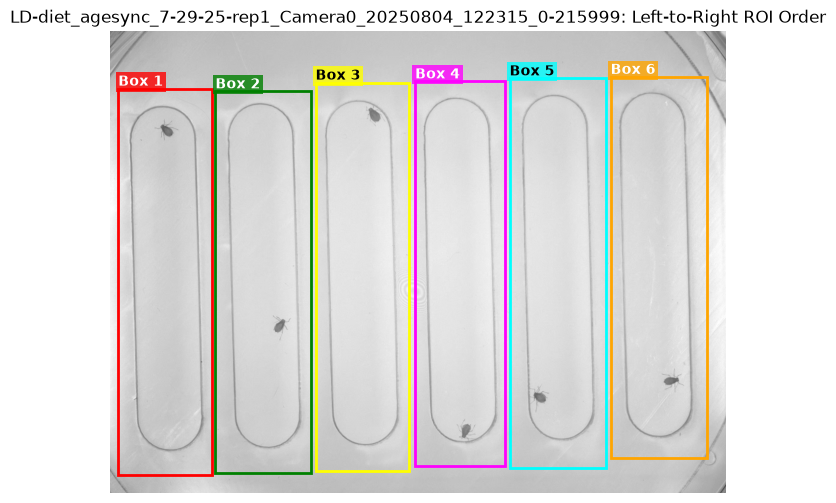

,label,x_min,y_min,x_max,y_max,width,height
0,1,27,191,338,1475,311,1284
1,2,350,200,669,1468,319,1268
2,3,683,171,993,1464,310,1293
3,4,1014,167,1314,1447,300,1280
4,5,1328,157,1647,1451,319,1294
5,6,1664,152,1983,1420,319,1268


In [9]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### LD - Diet - Rep 2

Loaded: LD-diet_agesync_8-8-25-rep2_Camera0_20250814_125919_0-215999.mp4
Successfully saved 6 boxes to LD-diet_agesync_8-8-25-rep2_Camera0_20250814_125919_0-215999.json


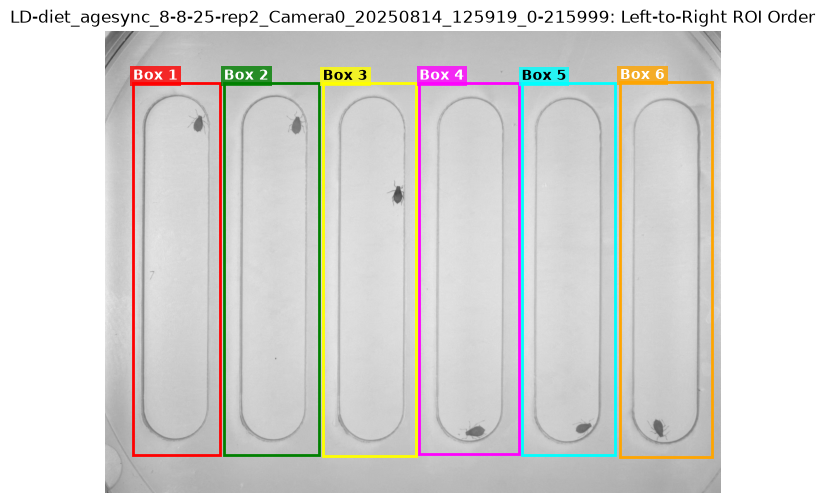

,label,x_min,y_min,x_max,y_max,width,height
0,1,94,171,382,1408,288,1237
1,2,396,171,713,1410,317,1239
2,3,725,172,1036,1413,311,1241
3,4,1046,171,1376,1405,330,1234
4,5,1386,172,1696,1410,310,1238
5,6,1713,169,2019,1417,306,1248


In [10]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### LD - Diet - Rep 3

Loaded: LD-diet_agesync_8-19-25-rep3_Camera0_20250825_131731_0-215999.mp4
Successfully saved 6 boxes to LD-diet_agesync_8-19-25-rep3_Camera0_20250825_131731_0-215999.json


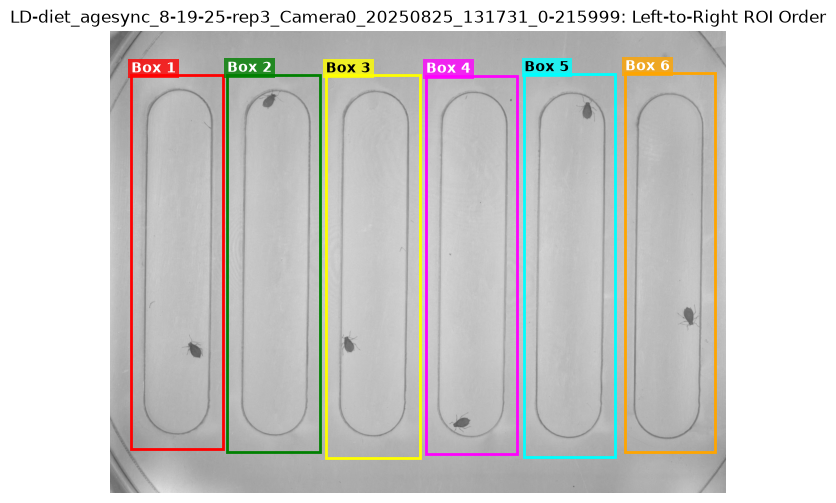

,label,x_min,y_min,x_max,y_max,width,height
0,1,70,147,375,1388,305,1241
1,2,389,145,696,1399,307,1254
2,3,717,147,1031,1420,314,1273
3,4,1050,148,1353,1406,303,1258
4,5,1377,143,1679,1415,302,1272
5,6,1712,140,2012,1398,300,1258


In [12]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### LD - Diet - Rep 4

Loaded: LD-diet_agesync_8-25-25-rep4_Camera0_20250901_123631_0-215999.mp4
Successfully saved 6 boxes to LD-diet_agesync_8-25-25-rep4_Camera0_20250901_123631_0-215999.json


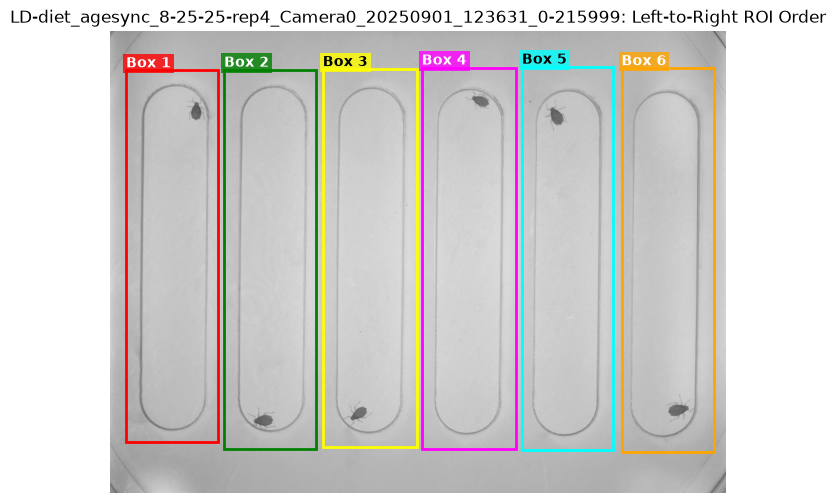

,label,x_min,y_min,x_max,y_max,width,height
0,1,53,130,360,1365,307,1235
1,2,379,128,683,1388,304,1260
2,3,707,126,1019,1382,312,1256
3,4,1036,121,1348,1388,312,1267
4,5,1369,118,1671,1394,302,1276
5,6,1700,123,2009,1398,309,1275


In [13]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### LD - Diet - Rep 5

Loaded: LD-diet_agesync_9-11-25-rep5_Camera0_20250918_122403_0-215999.mp4
Successfully saved 6 boxes to LD-diet_agesync_9-11-25-rep5_Camera0_20250918_122403_0-215999.json


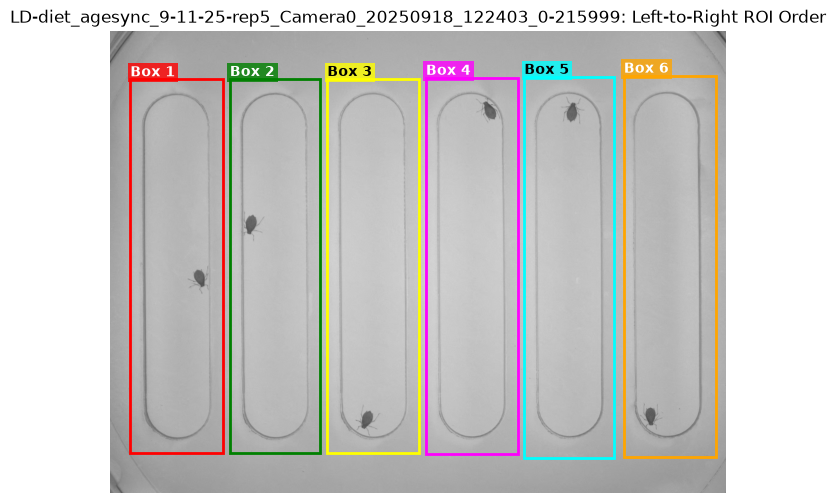

,label,x_min,y_min,x_max,y_max,width,height
0,1,67,160,375,1403,308,1243
1,2,398,159,696,1403,298,1244
2,3,722,159,1027,1401,305,1242
3,4,1050,155,1355,1406,305,1251
4,5,1377,152,1676,1420,299,1268
5,6,1708,148,2014,1417,306,1269


In [14]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### LD - Diet - Rep 6

Loaded: LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999.mp4
Successfully saved 6 boxes to LD-diet_agesync_9-18-25-rep6_Camera0_20250924_124210_0-215999.json


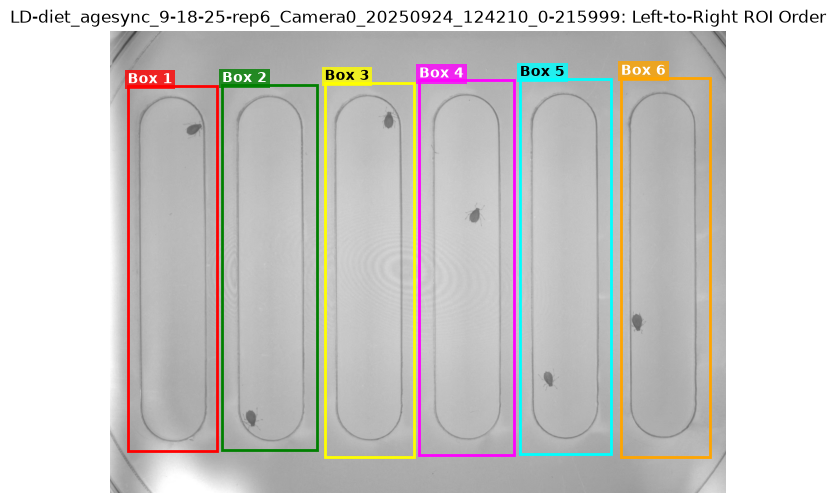

,label,x_min,y_min,x_max,y_max,width,height
0,1,58,183,355,1396,297,1213
1,2,372,179,689,1394,317,1215
2,3,713,172,1010,1417,297,1245
3,4,1027,164,1341,1410,314,1246
4,5,1362,159,1664,1405,302,1246
5,6,1698,155,1995,1415,297,1260


In [15]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### LD - Diet - Rep 7

Loaded: LD-diet_agesync_1-2-26-rep7_Camera0_20260109_125141_0-215999.mp4
Successfully saved 6 boxes to LD-diet_agesync_1-2-26-rep7_Camera0_20260109_125141_0-215999.json


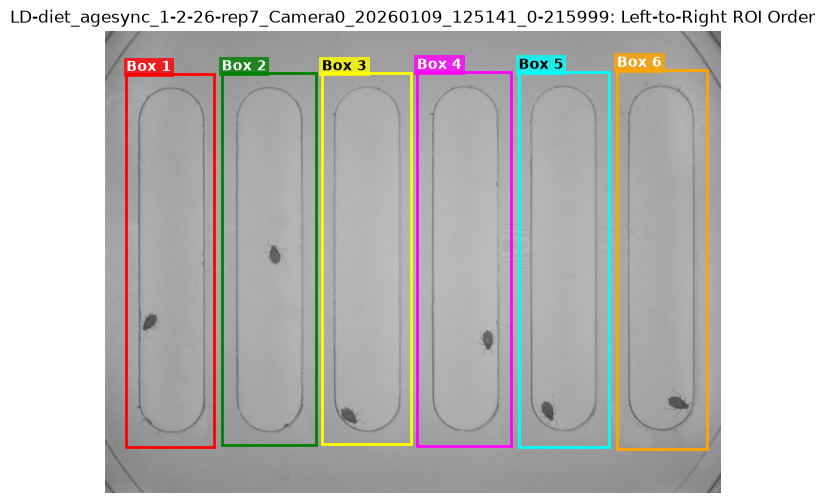

,label,x_min,y_min,x_max,y_max,width,height
0,1,72,142,364,1384,292,1242
1,2,389,140,701,1376,312,1236
2,3,722,140,1019,1374,297,1234
3,4,1038,135,1350,1379,312,1244
4,5,1376,135,1676,1381,300,1246
5,6,1703,128,2002,1388,299,1260


In [16]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### LD - Diet - Rep 8

Loaded: LD-diet_agesync_1-23-26-rep8_Camera0_20260130_134713_0-215999.mp4
Successfully saved 6 boxes to LD-diet_agesync_1-23-26-rep8_Camera0_20260130_134713_0-215999.json


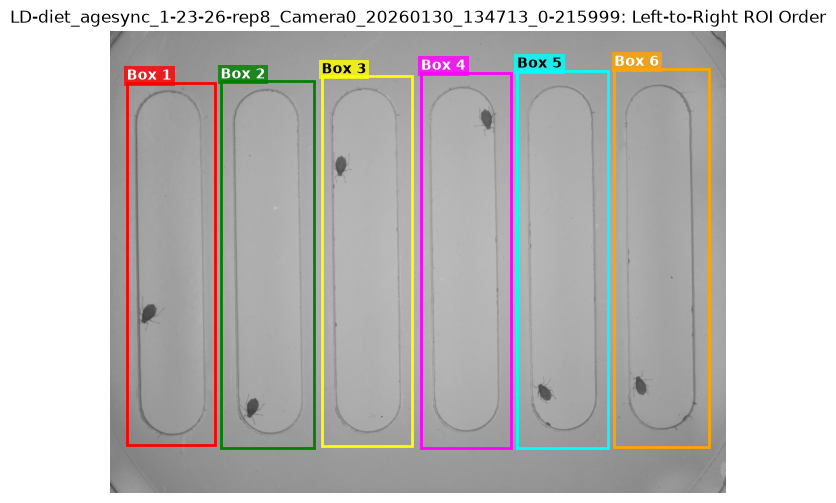

,label,x_min,y_min,x_max,y_max,width,height
0,1,55,171,350,1376,295,1205
1,2,367,167,676,1386,309,1219
2,3,703,150,1005,1379,302,1229
3,4,1033,138,1331,1386,298,1248
4,5,1353,131,1654,1386,301,1255
5,6,1676,125,1990,1384,314,1259


In [17]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### DD - Diet - Rep 1

Loaded: DD-diet_agesync_10-3-25-rep1_Camera0_20251009_125400_0-215999.mp4
Successfully saved 6 boxes to DD-diet_agesync_10-3-25-rep1_Camera0_20251009_125400_0-215999.json


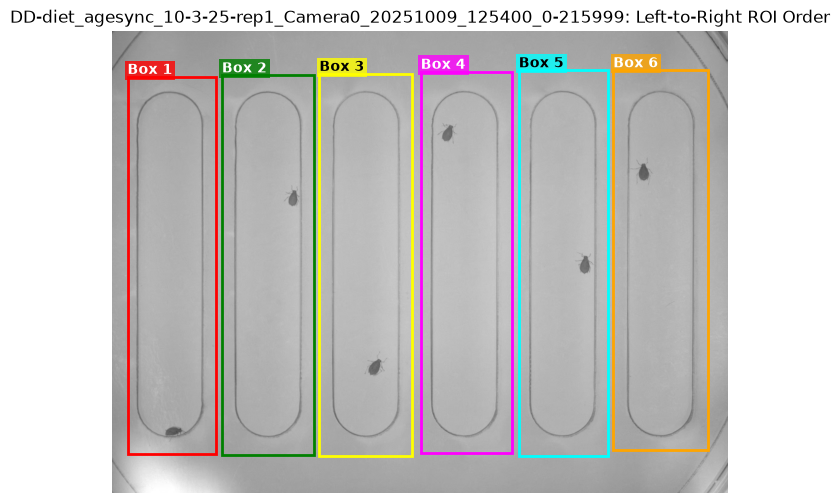

,label,x_min,y_min,x_max,y_max,width,height
0,1,51,152,345,1406,294,1254
1,2,365,147,671,1408,306,1261
2,3,689,142,998,1411,309,1269
3,4,1026,135,1329,1401,303,1266
4,5,1352,130,1647,1411,295,1281
5,6,1666,130,1981,1391,315,1261


In [18]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### DD - Diet - Rep 2

Loaded: DD_diet_agesync_10-23-25-rep2_Camera0_20251029_125846_0-215999.mp4
Successfully saved 6 boxes to DD_diet_agesync_10-23-25-rep2_Camera0_20251029_125846_0-215999.json


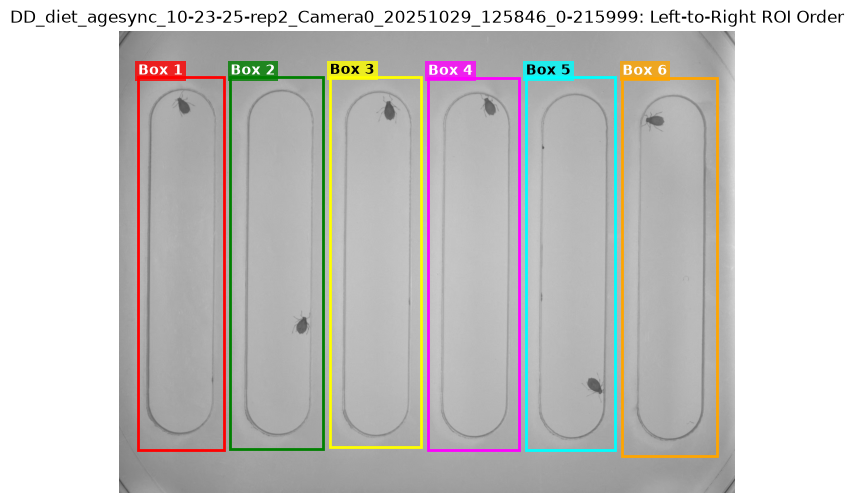

,label,x_min,y_min,x_max,y_max,width,height
0,1,63,154,350,1391,287,1237
1,2,370,154,679,1388,309,1234
2,3,700,152,1005,1382,305,1230
3,4,1027,155,1329,1393,302,1238
4,5,1352,154,1649,1391,297,1237
5,6,1673,155,1988,1411,315,1256


In [19]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### DD - Diet - Rep 3

Loaded: DD-diet_agesync_11-17-25-rep3_Camera0_20251123_124946_0-215999.mp4
Successfully saved 6 boxes to DD-diet_agesync_11-17-25-rep3_Camera0_20251123_124946_0-215999.json


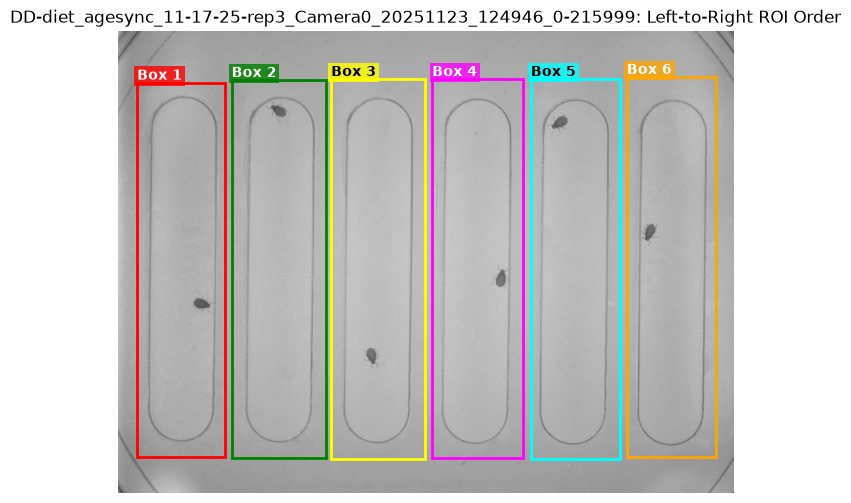

,label,x_min,y_min,x_max,y_max,width,height
0,1,65,171,358,1415,293,1244
1,2,379,162,693,1420,314,1258
2,3,710,159,1022,1423,312,1264
3,4,1046,159,1348,1418,302,1259
4,5,1374,159,1669,1422,295,1263
5,6,1693,152,1988,1415,295,1263


In [20]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### DD - Diet - Rep 4

Loaded: DD-diet_agesync_11-28-25-rep4_Camera0_20251204_132157_0-215999.mp4
Successfully saved 6 boxes to DD-diet_agesync_11-28-25-rep4_Camera0_20251204_132157_0-215999.json


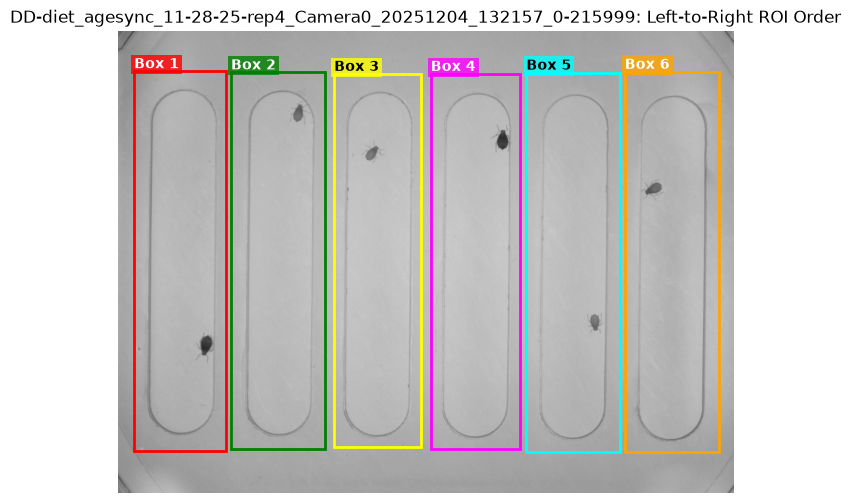

,label,x_min,y_min,x_max,y_max,width,height
0,1,55,133,360,1396,305,1263
1,2,377,137,688,1388,311,1251
2,3,720,142,1009,1381,289,1239
3,4,1041,142,1338,1389,297,1247
4,5,1359,138,1671,1398,312,1260
5,6,1686,135,1999,1398,313,1263


In [21]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### DD - Diet - Rep 5

Loaded: DD-diet_agesync_12-16-25-rep5_Camera0_20251223_133950_0-215999.mp4
Successfully saved 6 boxes to DD-diet_agesync_12-16-25-rep5_Camera0_20251223_133950_0-215999.json


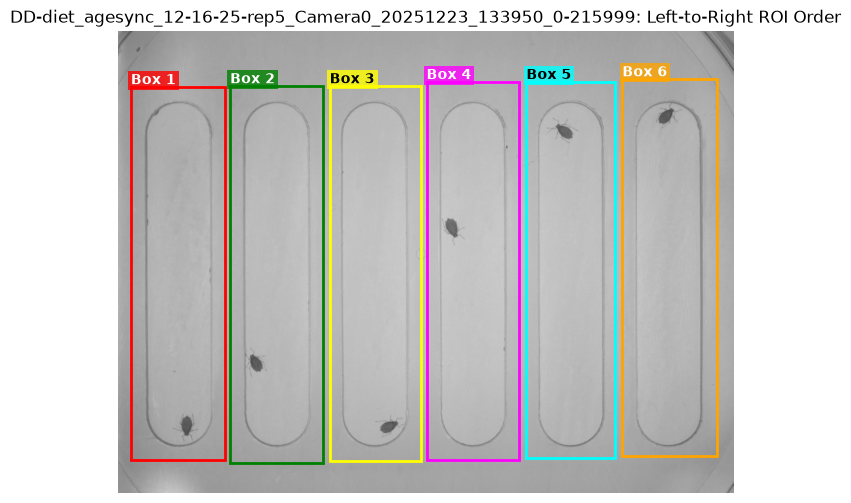

,label,x_min,y_min,x_max,y_max,width,height
0,1,44,186,358,1425,314,1239
1,2,374,183,684,1435,310,1252
2,3,705,183,1007,1430,302,1247
3,4,1027,169,1335,1427,308,1258
4,5,1359,169,1654,1420,295,1251
5,6,1678,160,1992,1411,314,1251


In [22]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### DD - Diet - Rep 6

Loaded: DD-diet_agesync_12-26-25-rep6_Camera0_20260102_134408_0-215999.mp4
Successfully saved 6 boxes to DD-diet_agesync_12-26-25-rep6_Camera0_20260102_134408_0-215999.json


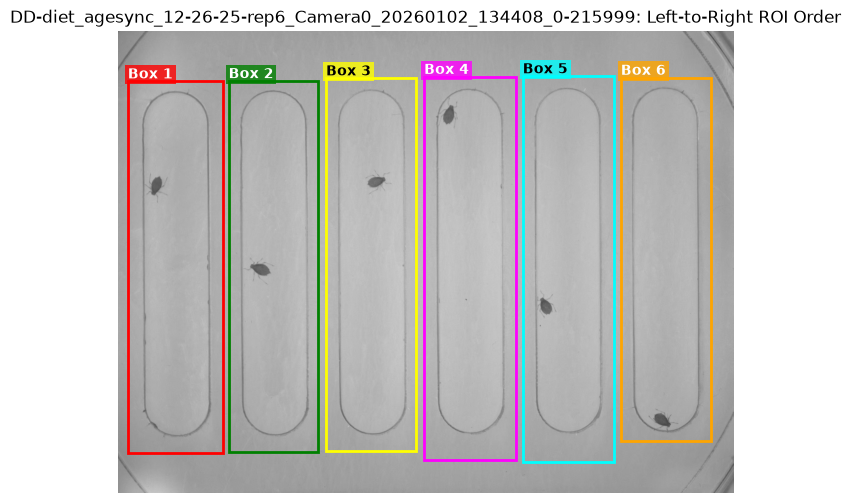

,label,x_min,y_min,x_max,y_max,width,height
0,1,34,167,350,1403,316,1236
1,2,369,166,666,1398,297,1232
2,3,693,157,993,1396,300,1239
3,4,1019,152,1324,1427,305,1275
4,5,1347,150,1649,1432,302,1282
5,6,1673,155,1971,1362,298,1207


In [23]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### DD - Diet - Rep 7

Loaded: DD-diet_agesync_2-11-26-rep7_Camera0_20260218_131644_0-215999.mp4
Successfully saved 6 boxes to DD-diet_agesync_2-11-26-rep7_Camera0_20260218_131644_0-215999.json


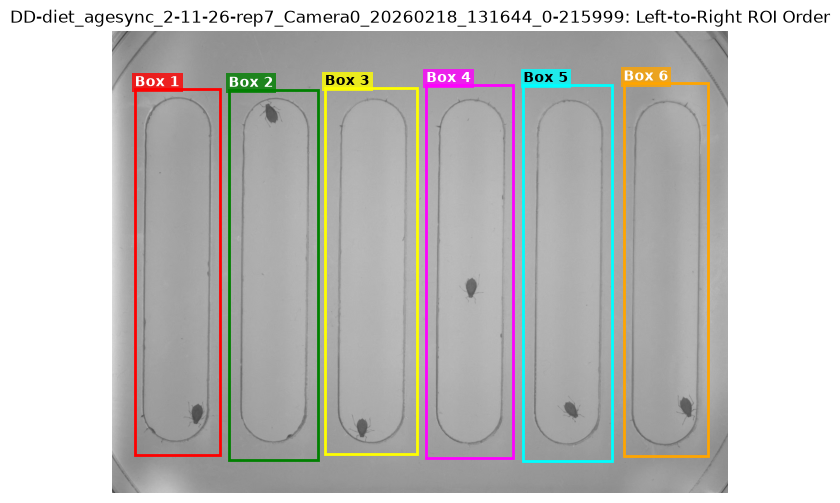

,label,x_min,y_min,x_max,y_max,width,height
0,1,75,193,357,1410,282,1217
1,2,387,195,683,1427,296,1232
2,3,707,189,1015,1405,308,1216
3,4,1044,179,1333,1418,289,1239
4,5,1367,179,1661,1428,294,1249
5,6,1700,174,1980,1413,280,1239


In [24]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])

### DD - Diet - Rep 8

Loaded: DD-diet_agesync_2-18-26-rep8_Camera0_20260225_133112_0-215999.mp4
Successfully saved 6 boxes to DD-diet_agesync_2-18-26-rep8_Camera0_20260225_133112_0-215999.json


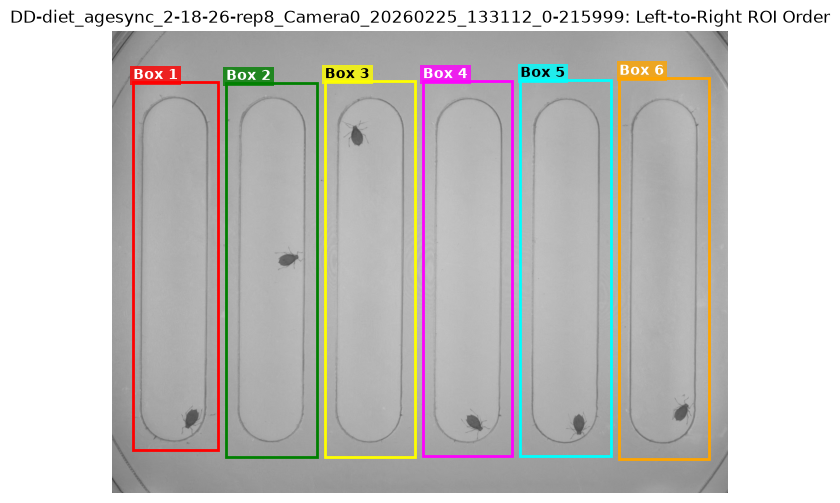

,label,x_min,y_min,x_max,y_max,width,height
0,1,70,169,353,1391,283,1222
1,2,379,172,681,1415,302,1243
2,3,707,166,1007,1417,300,1251
3,4,1033,166,1329,1411,296,1245
4,5,1357,162,1657,1413,300,1251
5,6,1686,155,1985,1422,299,1267


In [25]:
# Run the GUI tool
frame, boxes, base_name = grabROI(max_boxes=6)

# Render the frame and coordinates inline for visual verification
if frame is not None and len(boxes) > 0:
    plt.figure(figsize=(10, 6))
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    
    # Matching color palette for Matplotlib
    mpl_colors = ['red', 'green', 'yellow', 'magenta', 'cyan', 'orange']
    
    for box in boxes:
        x1, y1 = box["x_min"], box["y_min"]
        x2, y2 = box["x_max"], box["y_max"]
        label = box["label"]
        
        # Pick the distinct color based on the box label (1-6 mapped to 0-5)
        box_color = mpl_colors[(label - 1) % len(mpl_colors)]
        
        # Rectangle outline in distinct color
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=box_color, linewidth=2)
        plt.gca().add_patch(rect)
        
        # Label badge matching the box color (smart text contrast for yellow/cyan)
        text_color = 'black' if box_color in ['yellow', 'cyan'] else 'white'
        plt.text(
            x1, y1 - 10 if y1 > 20 else y1 + 20, 
            f"Box {label}", 
            color=text_color, 
            fontsize=10, 
            weight='bold',
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none', pad=2)
        )

    plt.title(f"{base_name}: Left-to-Right ROI Order")
    plt.axis("off")
    plt.show()

    # Display coordinate matrix directly in notebook history
    display(pd.DataFrame(boxes)[["label", "x_min", "y_min", "x_max", "y_max", "width", "height"]])